In [1]:
import pickle
import numpy as np
import pandas as pd

from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import r2_score
from vebir.metrics_utils import compute_compound_cors

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
REPO_ROOT = Path.cwd().resolve().parent
PREPROC_DIR = REPO_ROOT / "data" / "preprocessed" / "teflon"

GT_DIR = REPO_ROOT / "data" / "spectrabase" / "teflon"
LAB_DIR = REPO_ROOT / "data" / "raw" / "teflon" / "laboratory_samples"
PREPROC_DIR = REPO_ROOT / "data" / "preprocessed" / "teflon"
CORRECTIONS_DIR = REPO_ROOT / "data" / "corrections" / "teflon"

with open(PREPROC_DIR / "blanks_dict.pkl", "rb") as f:
    blanks_dict = pickle.load(f)
    
with open(PREPROC_DIR / "spectra_responses.pkl", "rb") as f:
    spectra_responses = pickle.load(f)

with open(GT_DIR / "ref_dict.pkl", "rb") as file:
    ref_dict = pickle.load(file)

CO2 = ref_dict["CO2"]
del ref_dict["CO2"]

H2O = np.array(pd.read_csv("../data/spectrabase/teflon/H2O_spectrum.csv"))
wn = np.sort(pd.read_csv(LAB_DIR / "zerofilling.txt", header=None).iloc[:, 0])

ncomp_grid = 1 + np.arange(54)
tau_grid = 0.1 * np.power(2.0, np.arange(-2, 3))
a, b = np.meshgrid(ncomp_grid, tau_grid)
grid = np.column_stack([a.ravel(), b.ravel()])

In [3]:
with open(CORRECTIONS_DIR / "ebs_als_dict_W.pkl", "rb") as f:
    ebs_als_dict_W = pickle.load(f)

with open(CORRECTIONS_DIR / "ebs_pb_dict_W.pkl", "rb") as f:
    ebs_pb_dict_W = pickle.load(f)
    
with open(CORRECTIONS_DIR / "veb_pb_dict.pkl", "rb") as f:
    veb_pb_dict = pickle.load(f)

In [4]:
def predict_load(A,f):
    Fhat = []
    for istar in range(A.shape[0]):
        fhat = np.sum(A*A[istar,:],axis=1)/np.sum(A[istar,:]**2)*f[istar]
        fhat[istar] = np.nan
        Fhat.append(fhat)
    Fhat = np.array(Fhat)    
    fhat = np.nanmean(Fhat, axis=0)
    
    return fhat 

def compute_compound_r2_scores(compound_corrections, f):
    r2_dict = {}
    for param in compound_corrections:
        A = compound_corrections[param]
        fhat = predict_load(A,f)
        r2_dict[param] = r2_score(f, fhat)
    
    return r2_dict

In [66]:
target_comp = "Ammonium sulfate"

In [67]:
if target_comp == "Ammonium sulfate":
    f = np.array(spectra_responses[target_comp]["AS"])
else:
    f = np.array(spectra_responses[target_comp]["OC"])

ref_profile = ref_dict[target_comp][:,1]
wn_gt = ref_dict[target_comp][:,0]

In [68]:
r2_dict = compute_compound_r2_scores(ebs_als_dict_W[target_comp], f)

max_cor = -1

for j in range(grid.shape[0]):
    corrections_dict = {}
    params = f"ncomp,tau = {int(grid[j, 0])},{grid[j, 1]}"
    for comp in ref_dict:
        corrections_dict[comp] = ebs_als_dict_W[comp][params]
    cors = compute_compound_cors(corrections_dict, ref_dict, wn)[target_comp]
    
    if np.mean(cors) > max_cor:
        max_cor = np.mean(cors)
        best_params = params
        corr_corrections = corrections_dict[target_comp]
        
print(best_params)

ncomp,tau = 6,0.2


In [69]:
mat = np.zeros([ncomp_grid.shape[0]-1,tau_grid.shape[0]])
thres = r2_dict[best_params]

for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        params = f"ncomp,tau = {ncomp_grid[i]},{tau_grid[j]}"
        mat[i,j] = r2_dict[params]
        
thres = r2_dict[best_params] 
mat[mat >= thres] = 1
mat[mat < thres] = 0

print(np.round(100*thres,2))

97.4


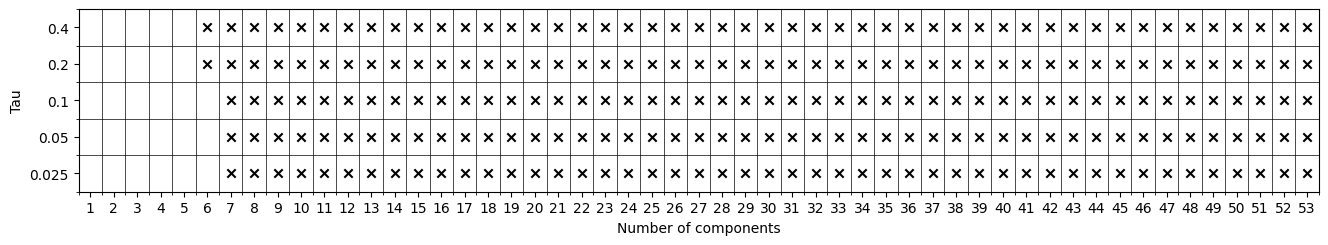

In [70]:
fig, ax = plt.subplots(figsize=(16, 2*16/13.5))
ax.imshow(np.zeros_like(mat.T), cmap="gray_r", aspect="auto")

rows, cols = np.where(mat.T == 1)
ax.scatter(cols, rows, marker='x', color='black')

ax.set_xticks(np.arange(-0.5, mat.shape[0], 1), minor=True)
ax.set_yticks(np.arange(-0.5, mat.shape[1], 1), minor=True)
ax.grid(which="minor", color="black", linestyle="-", linewidth=0.5)

ax.set_xticks(np.arange(mat.shape[0]))
ax.set_yticks(np.arange(mat.shape[1]))

ax.set_xticklabels(np.arange(mat.shape[0]))
ax.set_yticklabels(np.arange(mat.shape[1]))

ax.set_xlabel("Number of components")
ax.set_ylabel("Tau")

ax.set_xticklabels(ncomp_grid[:53])  # rotate if long
ax.set_yticklabels(tau_grid)

ax.invert_yaxis()
fig.savefig("../plots/metric_illustration.png", dpi=300, bbox_inches="tight")
plt.show()


In [71]:
params = "ncomp,tau = 53,0.4"
params = max(r2_dict, key=r2_dict.get)
print(params)
print(np.round(100*r2_dict[params],2))

ncomp,tau = 16,0.025
99.27


In [72]:
A1 = ebs_als_dict_W[target_comp][params]
v1 = (A1.T @ f) / np.sum(f**2)
#v1 = (v1 - np.min(v1)) / (np.max(v1) - np.min(v1))
v1 = v1/np.max(v1)
A2 = ebs_pb_dict_W[target_comp][best_params]
v2 = (A2.T @ f) / np.sum(f**2)
#v2 = (v2 - np.min(v2)) / (np.max(v2) - np.min(v2))
v2 = v2/np.max(v2)

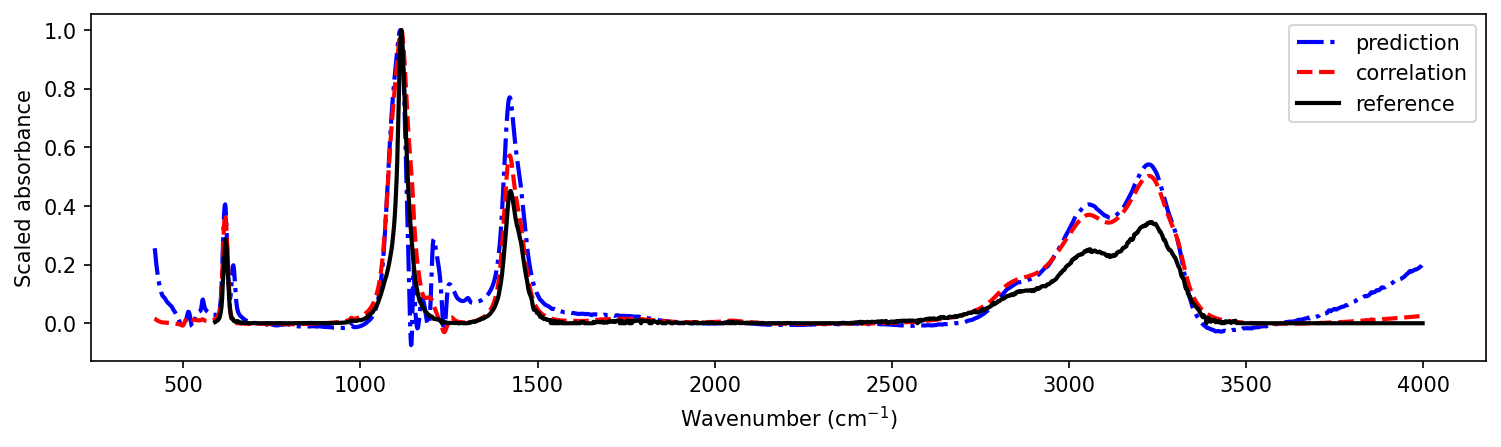

In [73]:
plt.figure(figsize=(12, 3), dpi=150)
plt.plot(wn, v1,c="b",linestyle="dashdot",label="prediction",linewidth=2)
plt.plot(wn, v2,c="r",linestyle="--",label="correlation",linewidth=2)
plt.plot(wn_gt, ref_profile / np.max(ref_profile),c="k",label="reference",linestyle="-",linewidth=2)
plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("Scaled absorbance")
plt.legend()
plt.savefig("../plots/metric_illustration_profiles.png", dpi=300, bbox_inches="tight")
plt.show()